# Język Python w Analizie Danych
# Wizualizacja danych przy użyciu MatPlotLib i Seaborn

### Zadanie 1
Wczytaj dane z pliku `data_plt_sns.csv` i zapoznaj się z nimi przeprowadzając podstawową analizę danych (np. wyświetl przykładowe dane, odczytaj typy danych, sprawdź czy nie ma braków, jeśli są to usuń). Wczytane dane będą wykorzystywane podczas kolejnych zadań.

In [18]:
import os, pandas as pd
csv_path = 'data/data_plt_sns.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Plik {csv_path} nie istnieje. Sprawdź ścieżkę.")
df = pd.read_csv(csv_path)
print('Kształt danych:', df.shape)
display(df.head())
print('\nTypy danych:')
print(df.dtypes)
print('\nBraki danych:')
print(df.isnull().sum())
if df.isnull().any().any():
    df = df.dropna().reset_index(drop=True)
    print('\nPo usunięciu braków - kształt danych:', df.shape)
else:
    print('\nBrak braków danych.')

Kształt danych: (1000, 15)


,brand,model,price_usd,ram_gb,storage_gb,camera_mp,battery_mah,display_size_inch,charging_watt,5g_support,os,processor,rating,release_month,year
0,Oppo,A98 111,855,16,128,108,6000,6.6,33,Yes,Android,Helio G99,3.8,February,2025
1,Realme,11 Pro+ 843,618,6,128,64,4500,6.9,100,Yes,Android,Tensor G4,4.4,August,2025
2,Xiaomi,Redmi Note 14 Pro 461,258,16,64,64,4000,6.8,44,Yes,Android,A18 Pro,4.1,March,2025
3,Vivo,V29e 744,837,6,512,48,4500,6.0,65,Yes,Android,Exynos 2400,4.1,August,2025
4,Apple,iPhone 16 Pro Max 927,335,12,128,200,5000,6.9,100,Yes,iOS,Dimensity 9300,3.5,February,2025



Typy danych:
brand                    str
model                    str
price_usd              int64
ram_gb                 int64
storage_gb             int64
camera_mp              int64
battery_mah            int64
display_size_inch    float64
charging_watt          int64
5g_support               str
os                       str
processor                str
rating               float64
release_month            str
year                   int64
dtype: object

Braki danych:
brand                0
model                0
price_usd            0
ram_gb               0
storage_gb           0
camera_mp            0
battery_mah          0
display_size_inch    0
charging_watt        0
5g_support           0
os                   0
processor            0
rating               0
release_month        0
year                 0
dtype: int64

Brak braków danych.


### Zadanie 2
a) Przedstaw za pomocą wykresu liniowego ilości urządzeń które miały premiery w kolejnych miesiącach.

b) Przedstaw za pomocą wykresu słupkowego średnią cenę urządzenia dla każdego producenta.

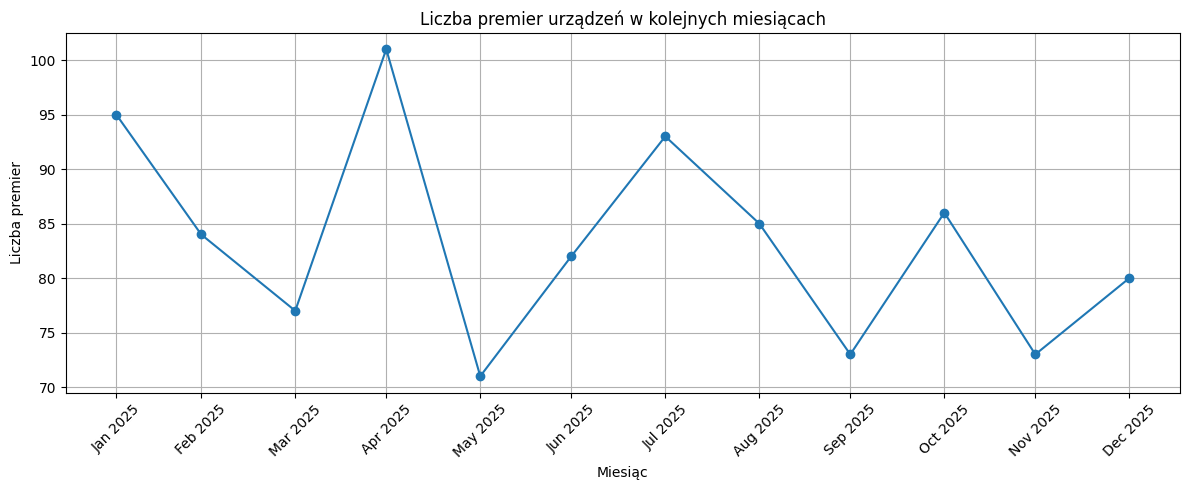

In [19]:
# a)
import matplotlib.pyplot as plt
df['release_date'] = pd.to_datetime(df['release_month'] + ' ' + df['year'].astype(str), format='%B %Y')
counts = df.groupby(pd.Grouper(key='release_date', freq='ME')).size().sort_index()
full_idx = pd.date_range(start=counts.index.min(), end=counts.index.max(), freq='ME')
counts = counts.reindex(full_idx, fill_value=0)
plt.figure(figsize=(12,5))
plt.plot(counts.index, counts.values, marker='o')
plt.title("Liczba premier urządzeń w kolejnych miesiącach")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba premier")
plt.xticks(counts.index, [d.strftime('%b %Y') for d in counts.index], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


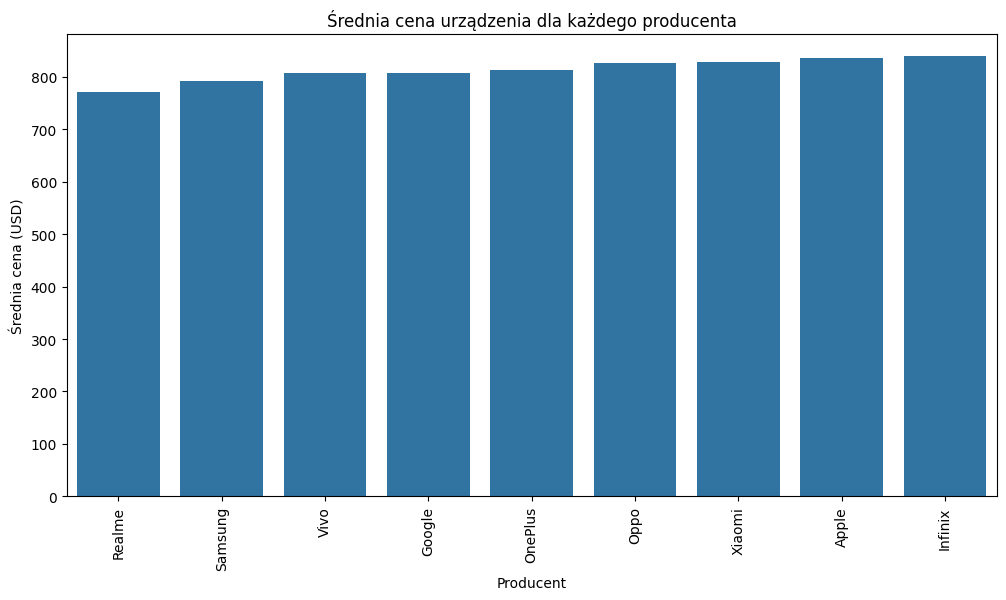

In [20]:
# b)
import seaborn as sns
brand_mean = df.groupby('brand')['price_usd'].mean().sort_values(ascending=True)
plt.figure(figsize=(12,6))
sns.barplot(x=brand_mean.index, y=brand_mean.values)
plt.title("Średnia cena urządzenia dla każdego producenta")
plt.xlabel("Producent")
plt.ylabel("Średnia cena (USD)")
plt.xticks(rotation=90)
plt.show()


### Zadanie 3
Przedstaw przy pomocy wykresu pudełkowego dystrybucję cen poszczególnych marek urządzeń posortowane po medianie.

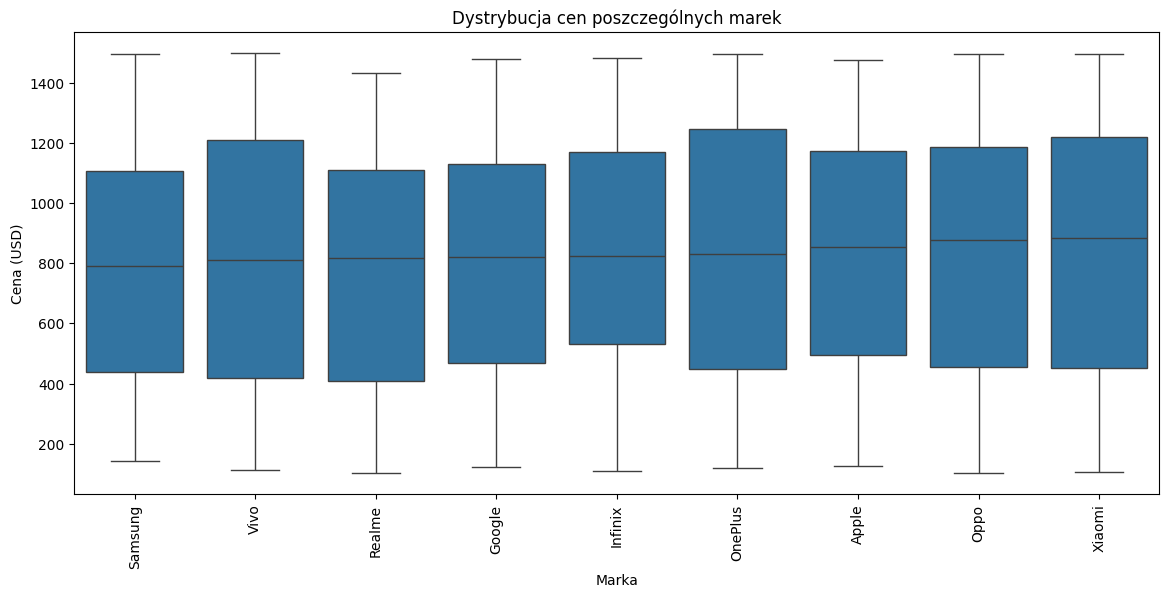

In [21]:
medians = df.groupby('brand')['price_usd'].median().sort_values()
order = medians.index
plt.figure(figsize=(14,6))
sns.boxplot(data=df, x='brand', y='price_usd', order=order)
plt.title("Dystrybucja cen poszczególnych marek")
plt.xlabel("Marka")
plt.ylabel("Cena (USD)")
plt.xticks(rotation=90)
plt.show()


### Zadanie 4
Utwórz 2 wykresy kołowe na jednym obrazie. Przedstaw ich pomocą stosunek liczby urządzeń obsługujących 5G oraz stosunek liczby telefonów z systemem Android oraz urządzeń z systemem IOS. Zaznacz na wykresie procentowy udział systemu oraz wyróżnij parametrem `explode` system IOS.

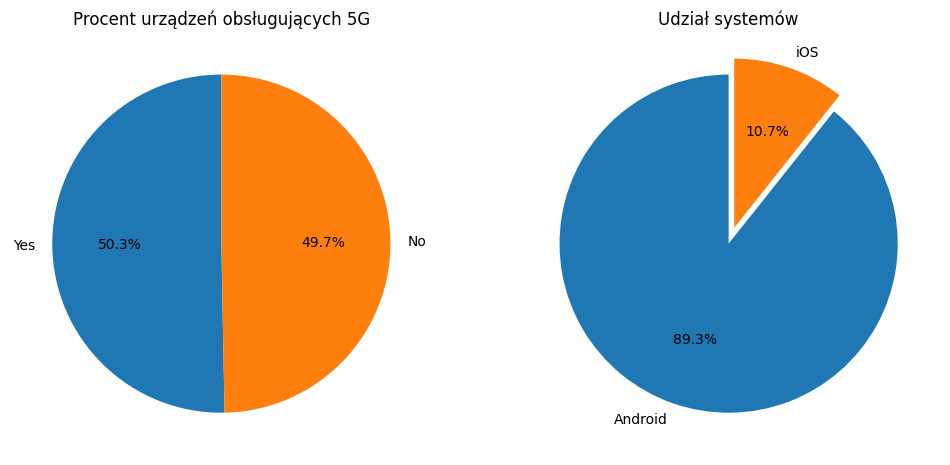

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))
counts_5g = df['5g_support'].value_counts()
axes[0].pie(counts_5g.values, labels=counts_5g.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title("Procent urządzeń obsługujących 5G")
counts_os = df['os'].value_counts()
explode = [0.1 if lab == 'iOS' else 0 for lab in counts_os.index]
axes[1].pie(counts_os.values, labels=counts_os.index, autopct='%1.1f%%', explode=explode, startangle=90)
axes[1].set_title("Udział systemów")
plt.show()


### Zadanie 5
Przedstaw za pomocą wykresu typu `scatterplot` urządzenia pogrupowane według cen i ratingu. Wykorzystaj przedziały podane w kodzie poniżej.

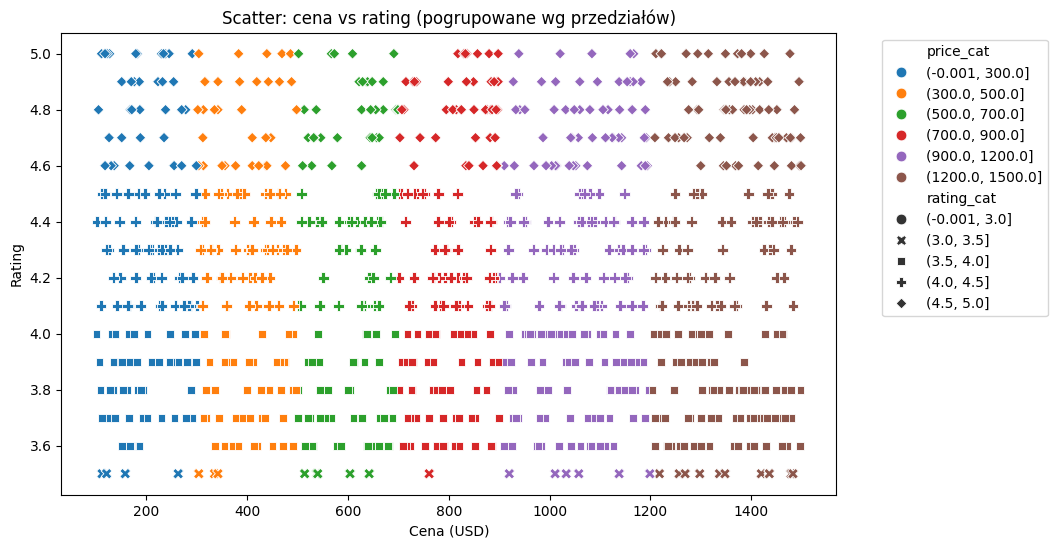

In [25]:
# Definicja przedziałów
price_bins = [0, 300, 500, 700, 900, 1200, 1500]
rating_bins = [0, 3, 3.5, 4, 4.5, 5]
df['price_cat'] = pd.cut(df['price_usd'], bins=price_bins, include_lowest=True)
df['rating_cat'] = pd.cut(df['rating'], bins=rating_bins, include_lowest=True)
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price_usd', y='rating', hue='price_cat', style='rating_cat', palette='tab10', s=60)
plt.title("Scatter: cena vs rating (pogrupowane wg przedziałów)")
plt.xlabel("Cena (USD)")
plt.ylabel("Rating")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
